In [1]:
# 1. Imports
%matplotlib ipympl
import os
import numpy as np
from scipy.ndimage import maximum_filter, minimum_filter, gaussian_filter
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
print(matplotlib.get_backend())
from IPython.display import display
from scipy.ndimage import uniform_filter1d, maximum_filter1d, minimum_filter1d, maximum_filter, minimum_filter, rotate
from tqdm.auto import tqdm
from scipy.ndimage import distance_transform_edt  # distance (in pixels) to nearest seed pixel
from scipy.ndimage import convolve                # fast neighborhood averaging via 
from datetime import datetime
import pandas as pd
import zarr
from numcodecs import Blosc

ipympl


In [2]:
# 2. Parameters
LUT = {
    "wavelength_nm": np.arange(390, 701, 5),
    "mac_od": np.array([0.04533,0.06489,0.0868,0.112,0.1365,0.1631,0.1981,0.2345,0.2618,0.2772,0.2884,0.308,0.3332,0.3486,0.35,0.3269,0.2996,0.2842,0.2786,0.2772,0.2688,0.2485,0.2093,0.1652,0.1211,0.0812,0.0525,0.0329,0.0175,0.00929,0.00459,0.00166,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
    "lens_od": np.array([2.5122,2.1306,1.7649,1.4257,1.13738,0.9063,0.72398,0.59572,0.4876,0.4081,0.34132,0.29998,0.26288,0.2438,0.2279,0.21306,0.20458,0.19292,0.18338,0.1749,0.16748,0.16006,0.1537,0.14628,0.1378,0.12932,0.12296,0.1166,0.11024,0.10494,0.09858,0.09222,0.08586,0.0795,0.0742,0.06784,0.06148,0.05512,0.04876,0.04346,0.03812,0.03286,0.02968,0.02544,0.02226,0.01908,0.01696,0.01484,0.01166,0.00848,0.0053,0.00424,0.00318,0.00106,0,0,0,0,0,0,0,0,0]),
    "cone_ext_parameters": np.array([0.417050601,0.002072146099,0.0001638878333,-1.922880605,-16.05774461,0.001575425685,0.0000511375521,0.00157980964,0.00006584275242,0.00006684015221,0.002310441807,0.00007313131766,0.00001862685404,0.002008124081,0.00005407174451,0.00000514735556,0.001455412882,0.00004217635152,4.80E-06,0.001809022392,0.00003866766734,2.99E-05,0.001757314922,0.00001473437751,1.51E-05,0.35000001,0.1248091545,0.02274730785,0.0009731002994], dtype=float),
    "input_photopigment_peak_s": 419,
    "input_photopigment_peak_m": 530,
    "input_photopigment_peak_l": 557.25,
    "input_ODmax_s": 0.35,
    "input_ODmax_m": 0.3,
    "input_ODmax_l": 0.3,
    "primary_r": np.array([0.15,0.00,0.00,0.00,0.16,0.67,2.27,4.65,9.27,14.71,20.17,28.36,32.79,26.87,15.82,8.33,5.12,3.28,2.11,1.45,1.00,0.95,0.93,0.89,1.11,1.33,1.43,1.65,1.54,1.37,1.14,1.07,0.77,0.82,0.72,1.13,3.86,20.89,83.73,217.09,406.93,617.30,767.04,841.61,880.56,874.64,833.56,786.86,735.62,683.48,626.69,553.89,502.62,469.58,427.00,386.31,342.35,305.56,262.91,227.58,199.75,179.59,161.84]),
    "primary_g": np.array([0.00,0.05,0.00,0.00,0.00,0.00,0.12,0.55,1.63,4.60,10.72,23.07,37.52,47.36,55.72,71.12,99.87,123.43,131.23,127.34,142.58,174.86,227.38,285.70,388.61,508.82,621.44,644.47,712.30,760.29,789.32,789.25,751.83,742.14,687.43,630.10,573.19,490.28,411.33,330.16,246.74,173.14,111.25,64.28,34.18,16.73,8.20,4.39,2.64,1.83,1.34,1.16,0.95,0.78,0.69,0.72,0.80,1.00,1.15,1.54,2.07,2.67,3.44]),
    "primary_b": np.array([0.21,0.13,0.00,0.00,0.89,4.87,16.55,46.70,118.50,249.45,450.46,819.32,1234.87,1291.28,944.04,599.84,417.24,281.30,181.82,121.72,97.11,91.72,89.71,87.65,86.12,79.72,66.47,48.76,40.28,33.82,29.70,23.65,17.67,12.50,8.21,5.86,4.69,4.07,3.65,3.21,2.82,2.50,2.20,1.87,1.82,1.72,1.90,2.13,2.45,2.96,3.63,4.32,5.13,5.98,6.58,7.01,6.84,6.51,5.91,5.18,4.75,4.65,4.22]),
    "sigma_center": 0.025,
    "sigma_surround": 0.165,
    "surround_ratio_lm": np.array([1/2, 1/2]),
    "surround_ratio_lms": np.array([1/3, 1/3, 1/3]),
}

n = len(LUT["wavelength_nm"])
keys = ["mac_od", "lens_od", "primary_r", "primary_g", "primary_b"]
for k in keys:
    if len(LUT[k]) != n:
        raise ValueError(f"{k} has {len(LUT[k])} entries, expected {n}")
                     
    

In [3]:
# 3. Carroll cone extinction equation
ext_p = LUT["cone_ext_parameters"]
letters = list("ABCDEFGHIJKLMNOPQRSTUVWXY")
p = dict(zip(letters, ext_p[:25]))

def _gauss(x, mu, sigma):
    return (1.0/np.sqrt(2.0*np.pi))*np.exp(-0.5*((x-mu)/sigma)**2)

def cone_log_extinction(wavelength_nm, lambda_max_nm, p, ref_nm=558.5):
    shift = np.log10(1.0/lambda_max_nm)-np.log10(1.0/ref_nm)
    x = 10.0**(np.log10(1.0/wavelength_nm)-shift)
    part1_inside = (-p["E"]+p["E"]*np.tanh(-((x-p["F"])/p["G"])))
    part1 = np.log10(part1_inside)+p["D"]+p["A"]*np.tanh(-((x-p["B"])/p["C"]))
    part2 = (
        -(p["J"]/p["I"])*_gauss(x,p["H"],p["I"])
        -(p["M"]/p["L"])*_gauss(x,p["K"],p["L"])
        -(p["P"]/p["O"])*_gauss(x,p["N"],p["O"])
        +(p["S"]/p["R"])*_gauss(x,p["Q"],p["R"])
        +(p["V"]/p["U"])*_gauss(x,p["T"],p["U"])/10.0
        +(p["Y"]/p["X"])*_gauss(x,p["W"],p["X"])/100.0
    )
    whole = part1+part2
    return whole
           

In [4]:
# 4. Compute cone extinction arrays
log_ext_s = cone_log_extinction(LUT["wavelength_nm"], LUT["input_photopigment_peak_s"], p)
log_ext_m = cone_log_extinction(LUT["wavelength_nm"], LUT["input_photopigment_peak_m"], p)
log_ext_l = cone_log_extinction(LUT["wavelength_nm"], LUT["input_photopigment_peak_l"], p)


In [5]:
# 5. effective cone spectral sensitivity with optical desity  
def apply_OD(cone_log_extinction, input_ODmax, mac_od, lens_od):
    cone_linear_extinction = 10.0**cone_log_extinction
    numerator = 1.0-10.0**(-(cone_linear_extinction*input_ODmax))
    denominator = 1.0 - 10.0**(-input_ODmax)
    step1 = np.log10(numerator/denominator)-lens_od-mac_od
    final = 10.0**(step1+2)
    return final

In [6]:
# 6. compute effective cone spectral sensitivity with optical desity
ext_s = apply_OD(log_ext_s, LUT["input_ODmax_s"], LUT["mac_od"], LUT["lens_od"])
ext_m = apply_OD(log_ext_m, LUT["input_ODmax_m"], LUT["mac_od"], LUT["lens_od"])
ext_l = apply_OD(log_ext_l, LUT["input_ODmax_l"], LUT["mac_od"], LUT["lens_od"])
ext_surround_lm = LUT["surround_ratio_lm"][0]*ext_m+LUT["surround_ratio_lm"][1]*ext_l

# Adding H2-connected mRGC model
ext_surround_lms = (LUT["surround_ratio_lms"][0]*ext_s+LUT["surround_ratio_lms"][1]*ext_m
                    +LUT["surround_ratio_lms"][2]*ext_l)

In [7]:
# 7. compute RGB primary quanta to white light [1,1,1] 
white = np.array([1.0,1.0,1.0])
yellow = np.array([1.0,1.0,0.0])
primaries = np.stack([LUT["primary_r"],LUT["primary_g"],LUT["primary_b"]], axis=1)
primary_white = (white*primaries).sum(axis=1)
primary_yellow = (yellow*primaries).sum(axis=1)
total_quanta_white = primary_white.sum()
total_quanta_yellow = primary_yellow.sum()

## alternative that uses the integral
# dlambda = LUT["wavelength_nm"][1] - LUT["wavelength_nm"][0]  # should be 5 nm
# total_quanta_white = primary_white.sum()*dlambda
# total_quanta_yellow = primary_yellow.sum()*dlambda


In [8]:
# 8. Find scalar to equalize total quantal response of L- and M-center to LM-surround

response_white_lm = np.sum(ext_surround_lm*primary_white)
response_white_l = np.sum(ext_l*primary_white)
response_white_m = np.sum(ext_m*primary_white)
response_white_s = np.sum(ext_s*primary_white) # Adding H2-connected mRGC model
response_white_lms = np.sum(ext_surround_lms*primary_white) # Adding H2-connected mRGC model

scalar_l = response_white_lm/response_white_l
scalar_m = response_white_lm/response_white_m
scalar_s = response_white_lm/response_white_s # Adding H2-connected mRGC model
scalar_lms = response_white_lm/response_white_lms # Adding H2-connected mRGC model

response_yellow_lm = np.sum(ext_surround_lm*primary_yellow)
response_yellow_l = np.sum(ext_l*primary_yellow)
response_yellow_m = np.sum(ext_m*primary_yellow)


In [9]:
# 9. Build 2D gaussian (and DoGs) receptive fields
radius = 1.05 # degrees
dx = 0.005 # pixels per degree
x = np.arange(-radius, radius+dx, dx)
X,Y = np.meshgrid(x,x)

# spatial kernal 
amp_center = 1.0
amp_surround = amp_center*(LUT["sigma_center"]**2)/(LUT["sigma_surround"]**2)

def gaussian_2D(X,Y,amp,sigma):
    return amp*np.exp(-(X**2+Y**2)/(2*sigma**2))

gaussian_center = gaussian_2D(X,Y,amp_center,LUT["sigma_center"])
gaussian_surround = gaussian_2D(X,Y,amp_surround,LUT["sigma_surround"])

rf_on = gaussian_center-gaussian_surround
rf_off = -rf_on

In [10]:
# 9b sanity check
integral_center = gaussian_center.sum()*dx*dx
integral_surround = gaussian_surround.sum()*dx*dx
print(integral_center, integral_surround, integral_center/integral_surround)
print(amp_surround)

print(scalar_l*response_white_l, response_white_lm)
print(scalar_m*response_white_m, response_white_lm)
print(scalar_s*response_white_s, scalar_lms*response_white_lms) # Adding H2-connected mRGC model

0.00392699081698741 0.003926990815587744 1.000000000356422
0.022956841138659322
1155423.701290184 1155423.701290184
1155423.701290184 1155423.701290184
1155423.701290184 1155423.701290184


In [11]:
# 10. check response under full white [1,1,1], or yellow [1,1,0], compute uniform field responses
dog_response_l_white = ((scalar_l*response_white_l)*gaussian_center.sum()*dx*dx-
                        (response_white_lm)*gaussian_surround.sum()*dx*dx)
dog_response_m_white = ((scalar_m*response_white_m)*gaussian_center.sum()*dx*dx-
                        (response_white_lm)*gaussian_surround.sum()*dx*dx)
dog_response_h2_white = ((scalar_s*response_white_s)*gaussian_center.sum()*dx*dx-
                         (scalar_lms*response_white_lms)*gaussian_surround.sum()*dx*dx)


dog_response_l_yellow = ((scalar_l*response_yellow_l)*gaussian_center.sum()*dx*dx-
                         (response_yellow_lm)*gaussian_surround.sum()*dx*dx)
dog_response_m_yellow = ((scalar_m*response_yellow_m)*gaussian_center.sum()*dx*dx-
                         (response_yellow_lm)*gaussian_surround.sum()*dx*dx)

print("L center under white light: ", (scalar_l*response_white_l)*gaussian_center.sum()*dx*dx)
print("M center under white light: ", (scalar_m*response_white_m)*gaussian_center.sum()*dx*dx)
print("surround under white light: ", (response_white_lm)*gaussian_surround.sum()*dx*dx)
print("DoG under white light (L-center, M-center, H2): ", dog_response_l_white, dog_response_m_white, dog_response_h2_white)
print("L center under yellow light: ", (scalar_l*response_yellow_l)*gaussian_center.sum()*dx*dx)
print("M center under yellow light: ", (scalar_m*response_yellow_m)*gaussian_center.sum()*dx*dx)
print("surround under yellow light: ", (response_yellow_lm)*gaussian_surround.sum()*dx*dx)
print("DoG under yellow light (L-center, M-center): ", dog_response_l_yellow, dog_response_m_yellow)
print("Percentage of center, DoG under yellow light (L-center, M-center): ", 
      dog_response_l_yellow/((scalar_l*response_yellow_l)*gaussian_center.sum()*dx*dx), 
      dog_response_m_yellow/((scalar_m*response_yellow_m)*gaussian_center.sum()*dx*dx))


L center under white light:  4537.338264696156
M center under white light:  4537.338264696156
surround under white light:  4537.338263078949
DoG under white light (L-center, M-center, H2):  1.617207090021111e-06 1.617207090021111e-06 1.617207090021111e-06
L center under yellow light:  4234.125064542216
M center under yellow light:  3980.384448817143
surround under yellow light:  4124.127673848554
DoG under yellow light (L-center, M-center):  109.99739069366206 -143.74322503141093
Percentage of center, DoG under yellow light (L-center, M-center):  0.02597877696500085 -0.03611289986677727


In [12]:
# 11. FFT 2D convolution
def fft_2d(image, kernel, pad_mode="reflect"):
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    Ih,Iw = image.shape
    Kh,Kw = kernel.shape
    pady = Kh//2
    padx = Kw//2
    imgpad = np.pad(image, ((pady,pady), (padx,padx)),mode=pad_mode)
    Ph,Pw = imgpad.shape
    out_shape = (Ph+Kh-1, Pw+Kw-1)
    # k0 = np.fft.ifftshift(kernel)
    y = np.fft.ifft2(np.fft.fft2(imgpad, out_shape)*np.fft.fft2(kernel, out_shape)).real
    r0 = Kh//2
    c0 = Kw//2
    convpad = y[r0:r0+Ph, c0:c0+Pw]
    return convpad[pady:pady+Ih, padx:padx+Iw]


In [13]:
# 12. create functions for the rgb images and responses by mRGCs

Ih = Iw = 1000
# (cy,cx) = (Ih//2,Iw//2)
yy = np.arange(Ih)
xx = np.arange(Iw)
X,Y = np.meshgrid(xx,yy)

# cone drive
weightl = np.array([np.sum(ext_l*LUT["primary_r"]),np.sum(ext_l*LUT["primary_g"]),np.sum(ext_l*LUT["primary_b"])],dtype=float)
weightm = np.array([np.sum(ext_m*LUT["primary_r"]),np.sum(ext_m*LUT["primary_g"]),np.sum(ext_m*LUT["primary_b"])],dtype=float)
weights = np.array([np.sum(ext_s*LUT["primary_r"]),np.sum(ext_s*LUT["primary_g"]),np.sum(ext_s*LUT["primary_b"])],dtype=float)
weightsurround = np.array([np.sum(ext_surround_lm*LUT["primary_r"]),
                           np.sum(ext_surround_lm*LUT["primary_g"]),np.sum(ext_surround_lm*LUT["primary_b"])],dtype=float)
weightsurround_h2 = np.array([np.sum(ext_surround_lms*LUT["primary_r"]),
                              np.sum(ext_surround_lms*LUT["primary_g"]),np.sum(ext_surround_lms*LUT["primary_b"])],dtype=float)

def draw_circle_img(Ih,Iw,X,Y,colorbg,colorcenter,kind="flat"):
    (cy,cx) = (Ih//2,Iw//2)
    r2 = (Y-cy)**2+(X-cx)**2
    R = (Ih//4)
    mask = r2<=R**2 
    img = np.broadcast_to(colorbg,(Ih,Iw,3)).copy()
    if kind == "flat":
        img[mask] = colorcenter
    elif kind == "gaussian":
        x01 = (X-(cx-R))/(2.0*R)
        npeaks = 5
        phase = 2.0*np.pi*npeaks*x01
        amp = 0.5*(1.0+np.cos(phase))
        img[mask] = amp[mask,None]*colorcenter
    else:
        raise ValueError(f"Unknown kind='{kind}'. Use 'flat' or 'gaussian'.")
    return img

def img2drive(img,weight):
    drive = img[...,0]*weight[0]+img[...,1]*weight[1]+img[...,2]*weight[2]
    return drive

def run_model(img):
    drivel = img2drive(img,weightl)
    drivem = img2drive(img,weightm)
    drives = img2drive(img,weights)
    drivesurround = img2drive(img,weightsurround)
    drivesurround_h2 = img2drive(img,weightsurround_h2)
    
    center_l = fft_2d(drivel, gaussian_center)
    center_m = fft_2d(drivem, gaussian_center)
    center_s = fft_2d(drives, gaussian_center) 
    surround = fft_2d(drivesurround, gaussian_surround)
    surround_h2 = fft_2d(drivesurround_h2, gaussian_surround) 
    
    respl_on = scalar_l*center_l-surround
    respm_on = scalar_m*center_m-surround
    respl_off = -respl_on
    respm_off = -respm_on

    respl_h2_on = (scalar_l*center_l+scalar_lms*surround_h2)-(scalar_s*center_s+surround) # Adding H2-connected mRGC model
    respm_h2_on = (scalar_m*center_m+scalar_lms*surround_h2)-(scalar_s*center_s+surround) # Adding H2-connected mRGC model
    respl_h2_off = -respl_h2_on # Adding H2-connected mRGC model
    respm_h2_off = -respm_h2_on # Adding H2-connected mRGC model
    
    return {"l_on": respl_on, "l_off": respl_off, 
            "m_on": respm_on, "m_off": respm_off,
            "l_h2_on": respl_h2_on, "m_h2_on": respm_h2_on,
            "l_h2_off": respl_h2_off, "m_h2_off": respm_h2_off}
    
keys_order = ["l_on", "l_off", "m_on", "m_off", "l_h2_on", "m_h2_on", "l_h2_off", "m_h2_off"]    
# margin = gaussian_surround.shape[0] // 2
# core_m_h2 = respm_h2_on[margin:-margin, margin:-margin]
# core_l_h2 = respl_h2_on[margin:-margin, margin:-margin]
# print("M-center ON mRGC with H2 connection: ", core_m_h2.min(), core_m_h2.max(), core_m_h2.mean())
# print("L-center ON mRGC with H2 connection: ", core_l_h2.min(), core_l_h2.max(), core_l_h2.mean())

In [14]:
# 13. Create rgb image set and their mRGC responses

colorbg = np.array([0.5,0.5,0.5], dtype=float) #gray
    
huecenter = {"red": np.array([1,0,0], dtype=float),
             "green": np.array([0,1,0], dtype=float),
             "blue": np.array([0,0,1], dtype=float), 
             "yellow": np.array([1,1,0], dtype=float),
             "white": np.array([1,1,1], dtype=float)}
    
intensitycenter = np.arange(0.02,1.0001,0.02)
total = len(huecenter)*len(intensitycenter) # for progress bar

results = []
pbar = tqdm(total=total, desc="generating rgb images and mRGC outputs")
for huename, huevec in huecenter.items():
    for intens in intensitycenter:
        colorcenter = np.clip(intens*huevec,0.0,1.0)
        img = draw_circle_img(Ih,Iw,X,Y,colorbg,colorcenter,kind="flat")
        outs = run_model(img)
        results.append({"colorbg": colorbg, "colorcenter": colorcenter, "hue": huename, "intensity": float(intens), "kind": "flat", "imgs": img, "outs": outs})
        pbar.update(1)

pbar.close()

generating rgb images and mRGC outputs:   0%|          | 0/250 [00:00<?, ?it/s]

In [15]:
# 14. Curvature extrema mask 

sigma_px = 0.5          # original: 0.5 ; smoothing 
amp_thresh = 0.0        # optional: ignore tiny-amplitude extrema (set >0 if get clutter) 
grad_tol_frac = 0.7     # how close to “derivative = 0” (smaller = stricter)
curv_tol_frac = 0.20    # original value: 0.1. How strong curvature must be (bigger = stricter)

def ridge_valley_mask(A, amp_thresh=0.0, grad_tol_frac=0.02, curv_tol_frac=0.10):
    A = np.asarray(A, dtype=float)  # ensure float array

    gy, gx = np.gradient(A)         # first derivatives
    gxx = np.gradient(gx, axis=1)   # second derivative d2/dx2
    gyy = np.gradient(gy, axis=0)   # second derivative d2/dy2
    gxy = np.gradient(gx, axis=0)   # mixed derivative d2/(dx dy)

    tr  = gxx + gyy                 # Hessian trace
    det = gxx * gyy - gxy * gxy     # Hessian determinant
    tmp = np.sqrt(np.maximum(0.0, (0.5 * tr) ** 2 - det))  # eigen helper

    lam1 = 0.5 * tr - tmp           # smaller eigenvalue (more negative curvature)
    lam2 = 0.5 * tr + tmp           # larger eigenvalue (more positive curvature)

    vx1 = gxy                       # eigenvector x-component (one valid form)
    vy1 = lam1 - gxx                # eigenvector y-component
    nrm = np.hypot(vx1, vy1) + 1e-12# normalize safely
    vx1 /= nrm
    vy1 /= nrm

    d1 = gx * vx1 + gy * vy1        # directional derivative along v1

    grad_ref = np.percentile(np.abs(d1), 99)     # robust scale for gradient
    curv_ref = np.percentile(np.abs(lam1), 99)   # robust scale for curvature
    grad_tol = grad_tol_frac * grad_ref          # tolerance for “~0 derivative”
    curv_tol = curv_tol_frac * curv_ref          # required curvature magnitude

    ridge_max = (np.abs(d1) < grad_tol) & (lam1 < -curv_tol) & (np.abs(A) > amp_thresh)  # bright ridge

    vx2 = -vy1                      # orthogonal direction to v1 
    vy2 =  vx1
    d2 = gx * vx2 + gy * vy2        # directional derivative along v2

    valley_min = (np.abs(d2) < grad_tol) & (lam2 > curv_tol) & (np.abs(A) > amp_thresh)  # dark valley

    return ridge_max | valley_min   # extrema-like mask (ridges + valleys)

# ----------------------------
# Smooth ALL RAW outs responses + compute extrema masks
for r in results:
    outs_smooth = {}
    outs_extrema_mask = {}
    outs_extrema_coords = {}
    outs_extrema_weighted = {}  # store mask*raw values (peaks carry values, others 0)
    for k in keys_order:
        A = r["outs"][k]  # RAW response
        As = gaussian_filter(A, sigma=sigma_px, mode="reflect")  # smoothed RAW
        outs_smooth[k] = As
        m = ridge_valley_mask(As, amp_thresh=amp_thresh, grad_tol_frac=grad_tol_frac, curv_tol_frac=curv_tol_frac)  # mask
        outs_extrema_mask[k] = m
        outs_extrema_coords[k] = np.argwhere(m)  # (row, col) coords
        outs_extrema_weighted[k] = A * m.astype(float)  # keep RAW values only where mask==True
    r["outs_smooth"] = outs_smooth
    r["outs_extrema_mask"] = outs_extrema_mask
    r["outs_extrema_coords"] = outs_extrema_coords
    r["outs_extrema_weighted"] = outs_extrema_weighted  # attach weighted images


In [16]:
# 15. Nearest-seed "fill-in" for ALL results
#     For each result r and each response key k:
#       - seeds W := outs_extrema_weighted[k]  (RAW outs values at extrema pixels, 0 elsewhere)
#       - filled[p] := W[nearest_seed(p)] for every non-seed pixel p (optionally within radius)
#       - also store dist_map[p] = distance (pixels) to nearest seed for future distance-weighting

# Settings
fillradius = None                 # None = fill everywhere; or set pixel int (e.g., 300) to restrict fill
beyondradius = False       # if radius is set: True keeps original outs outside radius; False sets to 0

# Loop through every stimulus/result and fill every response key
for r in results:                                             # iterate over all stimuli/responses
    outs_fill = {} # dict to hold filled images by key
    outs_dist = {} # dict to hold distance maps by key
    outs_fill_mask = {} # dict to hold update masks by key

    for k in keys_order:                                      # iterate over all response keys
        outs_img = np.asarray(r["outs"][k], dtype=float)      # RAW outs response (HxW)
        W = np.asarray(r["outs_extrema_weighted"][k], float)  # seeds: RAW values at extrema pixels (0 elsewhere)
        seed_mask = (W != 0.0)                                # True where seeds exist

        # If there are no seeds, we cannot propagate; keep outs as-is
        if not np.any(seed_mask):                             # no extrema seeds found
            outs_fill[k] = np.zeros_like(outs_img) # make image all 0's
            outs_dist[k] = np.full_like(outs_img, np.nan)  # undefined distances -> NaN
            outs_fill_mask[k] = np.zeros_like(seed_mask, dtype=bool)  # nothing updated
            continue                                          # go to next key

        # Compute distance-to-nearest-seed and nearest seed indices for every pixel
        # NOTE: EDT gives distance to nearest ZERO, so pass ~seed_mask (False at seeds, True elsewhere).
        dist_map, inds = distance_transform_edt(~seed_mask, return_indices=True)  # dist + nearest indices

        # Pull the value at the nearest seed for every pixel
        nearest_vals = W[inds[0], inds[1]]                    # nearest seed’s value at each pixel

        # Decide which pixels to fill: all non-seeds, optionally within radius
        fill_mask = ~seed_mask                              # never update seeds
        if fillradius is not None:                        # optionally restrict fill extent
            fill_mask = fill_mask & (dist_map <= float(fillradius))  # only within radius

        # Create filled output, starting from outs (so outside-radius behavior is controllable)
        filled = outs_img.copy()                              # initialize output with original outs
        filled[fill_mask] = nearest_vals[fill_mask]       # fill selected pixels with nearest seed value
        filled[seed_mask] = W[seed_mask]                      # explicitly clamp seeds to their seed values

        # If radius is used and want 0 outside radius, do that
        if (fillradius is not None) and (not beyondradius):  # user wants zeros outside radius
            beyond = (~seed_mask) & (dist_map > float(fillradius))      # beyond radius and not a seed
            filled[beyond] = 0.0                            # set far pixels to zero

        # Store outputs for this key
        outs_fill[k] = filled                       # filled response for key k
        outs_dist[k] = dist_map                      # distance to nearest seed for key k
        outs_fill_mask[k] = fill_mask            # update mask for key k

    # Attach per-result dictionaries (mirrors style of earlier steps)
    r["outs_fill"] = outs_fill            # filled responses for all keys
    r["outs_dist"] = outs_dist                  # distances for all keys
    r["outs_fill_mask"] = outs_fill_mask    # update masks for all keys


Saving to: outputs_16_viewer_20260119_102846


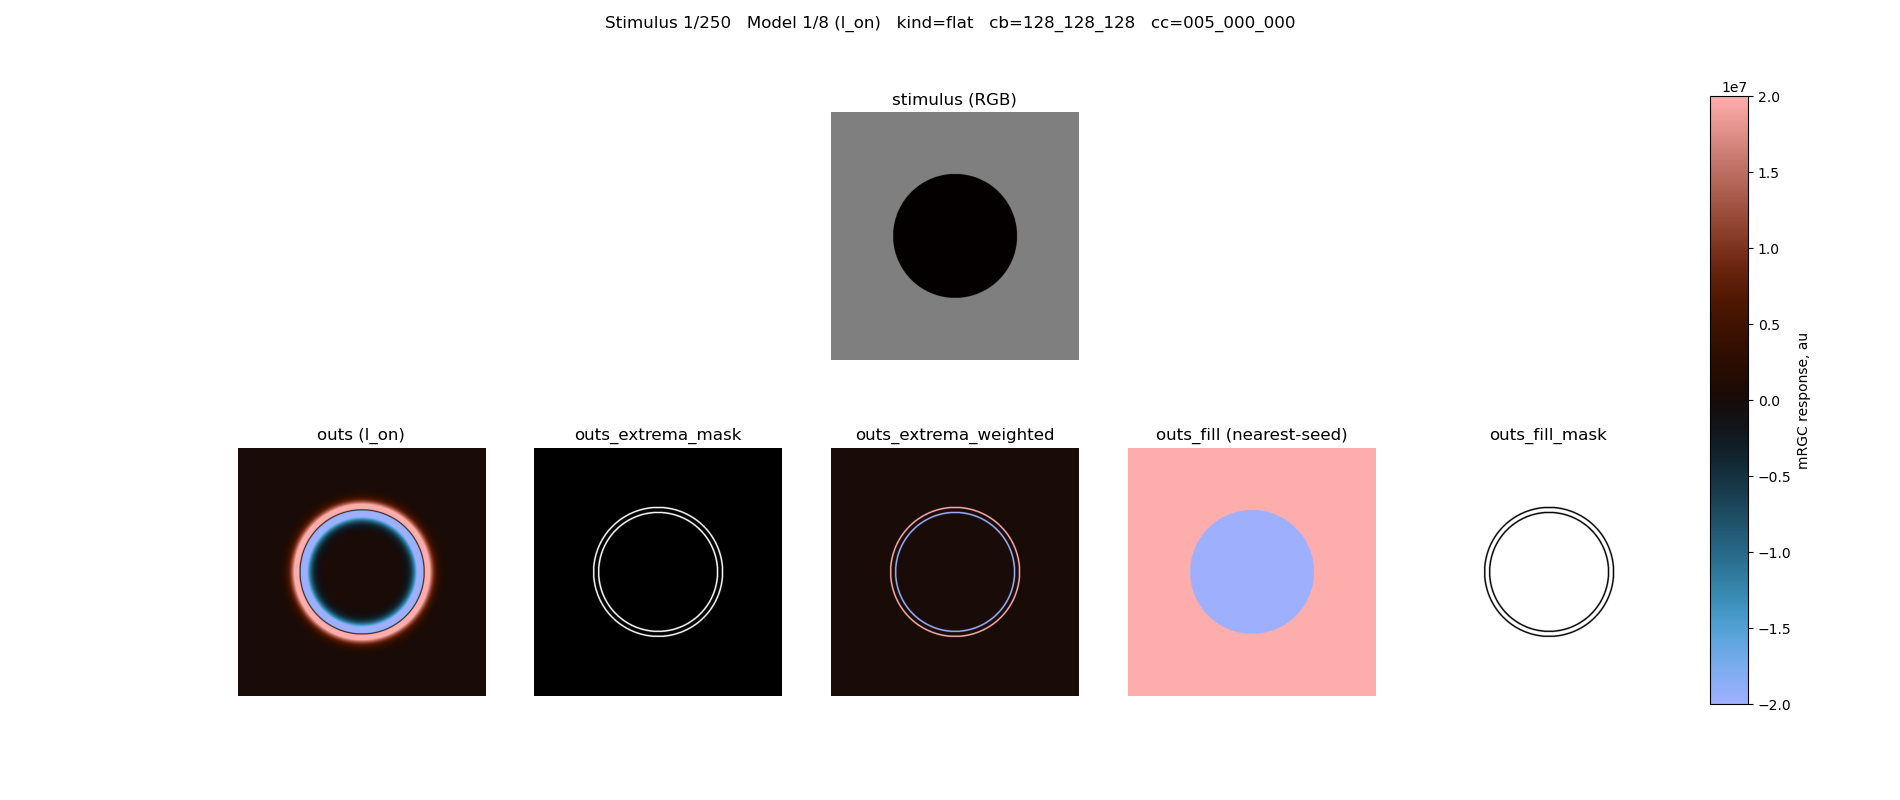

In [17]:
# 16. Interactive viewer — cycle through BOTH stimuli and model keys (outs-only + robust kind + no overwrite) - written by OpenAI

# ----------------------------
# USER SETTINGS
# - If model_keys is None: cycle through ALL models in keys_order
# - Or specify a subset like: ["m_on", "m_h2_on", "m_off", "m_h2_off"]
model_keys = None # optional subset selectiong, e.g. ["m_on", "m_h2_on", "m_off", "m_h2_off"] ; set to None to cycle all keys_order

# ----------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")  # e.g. 20260117_143012
outdir = f"outputs_16_viewer_{ts}"
os.makedirs(outdir, exist_ok=True)
print("Saving to:", outdir)

def rgb_code01(c):
    """Encode an RGB color in [0,1] as 0-255 integers for filenames."""
    c = np.asarray(c, dtype=float)
    c255 = np.round(255.0 * np.clip(c, 0.0, 1.0)).astype(int)
    return f"{c255[0]:03d}_{c255[1]:03d}_{c255[2]:03d}"

def infer_kind_from_img(img, colorbg, std_thresh=1e-4):
    """
    Robustly infer 'flat' vs 'gaussian' from the RGB stimulus.
    Works for red/green/blue because it checks variation across ALL channels.
    """
    img = np.asarray(img, dtype=float)                        # (H,W,3)
    bg  = np.asarray(colorbg, dtype=float)                    # (3,)

    # Pixels that differ from background in ANY channel -> disk region
    nonbg = np.any(np.abs(img - bg[None, None, :]) > 1e-6, axis=2)

    if not np.any(nonbg):
        return "unknown"

    v = img[nonbg, :]                                         # (N,3) RGB values inside disk
    std_rgb = np.std(v, axis=0)                               # std in each channel across disk
    max_std = float(np.max(std_rgb))                          # variation in ANY channel

    return "gaussian" if max_std > float(std_thresh) else "flat"

# ----------------------------
# Decide which model keys we will cycle
if model_keys is None:
    model_keys = list(keys_order)                             # default: all models
else:
    model_keys = list(model_keys)                             # ensure list

# ----------------------------
# Shared symmetric color scale across ALL stimuli AND ALL chosen model keys
# (keeps the color meaning consistent as you cycle models)
global_abs_max = 0.0
for r in results:
    for k in model_keys:
        for A in (r["outs"][k], r["outs_extrema_weighted"][k], r["outs_fill"][k]):
            A = np.asarray(A, dtype=float)
            global_abs_max = max(global_abs_max, float(np.max(np.abs(A))))

# vmin_all, vmax_all = -global_abs_max, global_abs_max
vmin_all, vmax_all = -2e7, 2e7

# ----------------------------
# Figure layout: 2 rows x 5 cols
# Top row: stimulus centered
# Bottom row (left->right): outs | outs_extrema_mask | outs_extrema_weighted | outs_fill | outs_fill_mask
fig, axs = plt.subplots(2, 5, figsize=(19, 8), sharex=True, sharey=True)

# Top row off by default
for j in range(5):
    axs[0, j].axis("off")

# Stimulus (RGB) centered above
stim_im = axs[0, 2].imshow(results[0]["imgs"], origin="lower")
axs[0, 2].set_title("stimulus (RGB)")
axs[0, 2].axis("off")

# ----------------------------
# Initialize handles from first stimulus + first model
r0 = results[0]
k0 = model_keys[0]

im_outs = axs[1, 0].imshow(r0["outs"][k0], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[1, 0].axis("off")
im_mask = axs[1, 1].imshow(r0["outs_extrema_mask"][k0].astype(float), origin="lower", cmap="gray", vmin=0.0, vmax=1.0); axs[1, 1].axis("off")
im_wgt  = axs[1, 2].imshow(r0["outs_extrema_weighted"][k0], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[1, 2].axis("off")
im_fill = axs[1, 3].imshow(r0["outs_fill"][k0], origin="lower", cmap="berlin", vmin=vmin_all, vmax=vmax_all); axs[1, 3].axis("off")
im_fmsk = axs[1, 4].imshow(r0["outs_fill_mask"][k0].astype(float), origin="lower", cmap="gray", vmin=0.0, vmax=1.0); axs[1, 4].axis("off")

# Bottom-row titles (model name updated dynamically in update())
t0 = axs[1, 0].set_title(f"outs ({k0})")
t1 = axs[1, 1].set_title("outs_extrema_mask")
t2 = axs[1, 2].set_title("outs_extrema_weighted")
t3 = axs[1, 3].set_title("outs_fill (nearest-seed)")
t4 = axs[1, 4].set_title("outs_fill_mask")

# One shared colorbar (for response-like panels)
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.12, 0.02, 0.76])
cbar = fig.colorbar(im_outs, cax=cax)
cbar.set_label("mRGC response, au")

# ----------------------------
state = {
    "i_stim": 0,
    "i_model": 0,
    "N_stim": len(results),
    "N_model": len(model_keys),
}

def update():
    r = results[state["i_stim"]]
    k = model_keys[state["i_model"]]

    # stimulus
    stim_im.set_data(r["imgs"])

    # response panels for current model key
    im_outs.set_data(r["outs"][k])
    im_mask.set_data(r["outs_extrema_mask"][k].astype(float))
    im_wgt.set_data(r["outs_extrema_weighted"][k])
    im_fill.set_data(r["outs_fill"][k])
    im_fmsk.set_data(r["outs_fill_mask"][k].astype(float))

    # update the model label in the first bottom title
    axs[1, 0].set_title(f"outs ({k})")

    # robust kind detection (cache it so it stays consistent)
    kind = r.get("kind", infer_kind_from_img(r["imgs"], r["colorbg"]))
    r["kind"] = kind

    # suptitle
    cb = rgb_code01(r["colorbg"])
    cc = rgb_code01(r["colorcenter"])
    fig.suptitle(
        f"Stimulus {state['i_stim']+1}/{state['N_stim']}   "
        f"Model {state['i_model']+1}/{state['N_model']} ({k})   "
        f"kind={kind}   cb={cb}   cc={cc}",
        fontsize=12
    )

    fig.canvas.draw_idle()

def save_current(dpi=200):
    r = results[state["i_stim"]]
    k = model_keys[state["i_model"]]

    cb = rgb_code01(r["colorbg"])
    cc = rgb_code01(r["colorcenter"])

    # use cached kind if present; otherwise infer robustly
    kind = r.get("kind", infer_kind_from_img(r["imgs"], r["colorbg"]))
    r["kind"] = kind

    # include stimulus index + model key => no overwrite
    fname = (
        f"stim{state['i_stim']+1:03d}_"
        f"model{k}_"
        f"cb{cb}_cc{cc}_kind{kind}_viewer16.png"
    )
    fpath = os.path.join(outdir, fname)
    fig.savefig(fpath, dpi=dpi, bbox_inches="tight")
    print(f"Saved {fpath}")

def on_key(event):
    # Stimulus navigation
    if event.key in ("right", "n", " "):
        state["i_stim"] = (state["i_stim"] + 1) % state["N_stim"]
        update()
    elif event.key in ("left", "p", "backspace"):
        state["i_stim"] = (state["i_stim"] - 1) % state["N_stim"]
        update()

    # Model navigation
    elif event.key in ("up", "m"):  # next model
        state["i_model"] = (state["i_model"] + 1) % state["N_model"]
        update()
    elif event.key in ("down", "shift+m"):  # prev model (NOTE: shift+m may not fire; down arrow always works)
        state["i_model"] = (state["i_model"] - 1) % state["N_model"]
        update()

    # Save
    elif event.key == "s":
        save_current()

    # Quit
    elif event.key in ("q", "escape"):
        plt.close(fig)

fig.canvas.mpl_connect("key_press_event", on_key)

update()
plt.show()


In [18]:
# 17. Save imgs, outs, outs_fill, keys_order, and metadata to a Zarr store ---

# ----------------------------
# 1) Create an output folder and file paths
ts = datetime.now().strftime("%Y%m%d_%H%M%S")             # timestamp string
outdir = f"export_retina_{ts}"                            # output folder name
os.makedirs(outdir, exist_ok=True)                        # create folder if missing

zarr_path = os.path.join(outdir, "dataset.zarr")          # Zarr store (directory)
meta_path = os.path.join(outdir, "metadata.csv")          # metadata table file

# ----------------------------
# 2) Read basic dimensions from the first stimulus
N = len(results)                                          # number of stimuli
H, W, C = results[0]["imgs"].shape                         # image shape (C should be 3)
K = len(keys_order)                                       # number of response maps per stimulus

# ----------------------------
# 3) Create the Zarr store and save keys_order as an attribute
root = zarr.open(zarr_path, mode="w")                      # create/overwrite store
root.attrs["keys_order"] = list(keys_order)                # save channel/key names (critical for later)

# ----------------------------
# 4) Choose compression + chunk sizes (chunks enable fast partial reads)
compressor = Blosc(cname="zstd", clevel=3, shuffle=Blosc.BITSHUFFLE)  # good default
chunk_hw = 256                                             # chunk tile size in pixels

# ----------------------------
# 5) Create datasets in the Zarr store
imgs_z = root.create_dataset(                               # RGB stimuli
    name="imgs",
    shape=(N, H, W, C),
    chunks=(1, chunk_hw, chunk_hw, C),                      # 1 stimulus per chunk, tiled in H/W
    dtype="f4",                                             # float32 (no downscaling)
    compressor=compressor
)

outs_z = root.create_dataset(                               # RAW response maps
    name="outs",
    shape=(N, K, H, W),                                     # (stimulus, key, y, x)
    chunks=(1, 1, chunk_hw, chunk_hw),                      # 1 stimulus, 1 key per chunk
    dtype="f4",                                             # float32
    compressor=compressor
)

outs_fill_z = root.create_dataset(                          # FILLED response maps
    name="outs_fill",
    shape=(N, K, H, W),
    chunks=(1, 1, chunk_hw, chunk_hw),
    dtype="f4",                                             # float32
    compressor=compressor
)

# ----------------------------
# 6) Write data one stimulus at a time (memory-friendly)
for i, r in enumerate(results):                             # loop over stimuli
    imgs_z[i] = np.asarray(r["imgs"], dtype=np.float32)     # save RGB image

    for j, k in enumerate(keys_order):                      # loop over response keys
        outs_z[i, j] = np.asarray(r["outs"][k], dtype=np.float32)          # save RAW map
        outs_fill_z[i, j] = np.asarray(r["outs_fill"][k], dtype=np.float32)# save FILLED map

# ----------------------------
# 7) Build and save metadata (one row per stimulus)
meta_rows = []                                              # list of dicts -> DataFrame

for i, r in enumerate(results):                             # loop over stimuli
    cb = np.asarray(r.get("colorbg", [np.nan, np.nan, np.nan]), dtype=float)      # background RGB
    cc = np.asarray(r.get("colorcenter", [np.nan, np.nan, np.nan]), dtype=float)  # center RGB

    meta_rows.append({                                      # one row per stimulus
        "stim_id": i,                                       # matches index i in Zarr arrays
        "hue": r.get("hue", ""),                            # hue label
        "intensity": r.get("intensity", np.nan),            # intensity scalar
        "kind": r.get("kind", ""),                          # "flat" (for now)
        "bg_r": float(cb[0]), "bg_g": float(cb[1]), "bg_b": float(cb[2]),         # background RGB
        "center_r": float(cc[0]), "center_g": float(cc[1]), "center_b": float(cc[2]), # center RGB
    })

meta_df = pd.DataFrame(meta_rows)                           # make DataFrame
meta_df.to_csv(meta_path, index=False)                      # save metadata CSV

# ----------------------------
# 8) Print where things were saved
print("Saved Zarr store:", zarr_path)                       # where arrays live
print("Saved metadata  :", meta_path)                       # where table lives
print("Zarr datasets   :", list(root.array_keys()))         # list datasets written


Saved Zarr store: export_retina_20260119_105329/dataset.zarr
Saved metadata  : export_retina_20260119_105329/metadata.csv
Zarr datasets   : ['imgs', 'outs', 'outs_fill']
